# Impact of Covid-19 on US road accidents

## Setup

In [116]:
from pyspark import sql, SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import month
import folium
import matplotlib.pyplot as plt
from pyspark_dist_explore import hist
import numpy as np
from branca.element import Figure

spark = (SparkSession.builder
         .master("local")
         .appName("covid-vs-accidents")
         .getOrCreate())



## Load data

In [143]:
accidents = spark.read.csv('./data/accidents.csv', header=True)
covid = spark.read.csv('./data/covid.csv', header=True)

accidents.createOrReplaceTempView("accidents")
covid.createOrReplaceTempView("covid")

## Data exploration

In [144]:
covid.show()


+----------+-----------+----------+-----+-----+------+
|      date|     county|     state| fips|cases|deaths|
+----------+-----------+----------+-----+-----+------+
|2020-01-21|  Snohomish|Washington|53061|    1|     0|
|2020-01-22|  Snohomish|Washington|53061|    1|     0|
|2020-01-23|  Snohomish|Washington|53061|    1|     0|
|2020-01-24|       Cook|  Illinois|17031|    1|     0|
|2020-01-24|  Snohomish|Washington|53061|    1|     0|
|2020-01-25|     Orange|California|06059|    1|     0|
|2020-01-25|       Cook|  Illinois|17031|    1|     0|
|2020-01-25|  Snohomish|Washington|53061|    1|     0|
|2020-01-26|   Maricopa|   Arizona|04013|    1|     0|
|2020-01-26|Los Angeles|California|06037|    1|     0|
|2020-01-26|     Orange|California|06059|    1|     0|
|2020-01-26|       Cook|  Illinois|17031|    1|     0|
|2020-01-26|  Snohomish|Washington|53061|    1|     0|
|2020-01-27|   Maricopa|   Arizona|04013|    1|     0|
|2020-01-27|Los Angeles|California|06037|    1|     0|
|2020-01-2

In [119]:
accidents.show(1, truncate=False, vertical=True)

-RECORD 0-------------------------------------------------------------------------------------------
 ID                    | A-2716600                                                                  
 Severity              | 3                                                                          
 Start_Time            | 2016-02-08 00:37:08                                                        
 End_Time              | 2016-02-08 06:37:08                                                        
 Start_Lat             | 40.10891                                                                   
 Start_Lng             | -83.09286                                                                  
 End_Lat               | 40.11206                                                                   
 End_Lng               | -83.03187                                                                  
 Distance(mi)          | 3.23                                                              

### Get number of total accidents for each state

In [120]:
states = accidents.groupBy("State").count().sort("count")

state_names = np.array(states.select("State").collect())
counts = np.array(states.select("count").collect())

### States sorted by total accumulated accidents

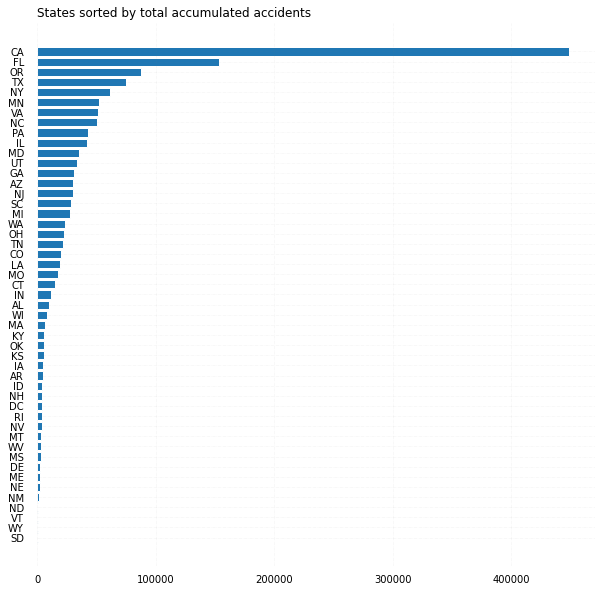

In [121]:
fig, ax = plt.subplots()

ax.barh(state_names[:,0], counts[:,0], edgecolor="white", linewidth=1)

for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)

ax.grid(b=True, color='grey',
        linestyle='-.', linewidth=0.5,
        alpha=0.1)

# Add Plot Title 
ax.set_title('States sorted by total accumulated accidents',
             loc='left', )
fig.set_figwidth(10)
fig.set_figheight(10)
plt.show()

In [122]:
m = folium.Map(location=[28.0902, -95.7129], zoom_start=5)
map_figure = Figure(width=550,height=350)
m